# 04 - Optimizacion de hiperparametros (modelos supervisados)

## Contexto

Este notebook implementa la **Fase 6** del proyecto y cubre la rubrica **IEE 2.3.1 (30%)** del encargo grupal. La rubrica exige:

> Implementa optimizacion exhaustiva con **GridSearchCV y RandomizedSearchCV** documentando el impacto.

Usar solo uno de los dos metodos baja la nota a 80%; este notebook usa **ambos**.

**Modelos tuneados** (los top 2 por tarea segun la CV del notebook 03):

| Tarea | Modelo | Metodo asignado | Razon |
|---|---|---|---|
| Regresion | Ridge | GridSearchCV | Espacio 1-D (alpha), barato y exhaustivo es exacto. |
| Regresion | GradientBoostingRegressor | RandomizedSearchCV | Espacio 5-D, exhaustivo seria prohibitivo. |
| Clasificacion | LogisticRegression | GridSearchCV | Espacio 2-D pequeño, exhaustivo cabe. |
| Clasificacion | GradientBoostingClassifier | RandomizedSearchCV | Espacio 5-D, mismo argumento que en regresion. |

**Nota sobre la seleccion de modelos:** en regresion, el notebook 03 dejo a `Ridge` y `LinearRegression` empatados en R^2. `LinearRegression` no tiene hiperparametros tuneables relevantes, asi que el segundo slot lo ocupa el siguiente en ranking — `GradientBoostingRegressor`.

La logica reutilizable de tuning vive en `src/hyperparameter_tuning.py`; este notebook orquesta, justifica grids y visualiza.


## Setup del entorno (Colab o local)

Mismo patron que los notebooks 02 y 03. Detecta el entorno y, en Colab, clona el repo `devsal-ml` desde `main` antes de continuar.


In [1]:
import os
import sys
import subprocess
from pathlib import Path

REPO_URL = 'https://github.com/Nicossm/devsal-ml.git'
REPO_BRANCH = 'main'
REPO_NAME = 'devsal-ml'

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    base = Path('/content')
    repo_dir = base / REPO_NAME
    if not repo_dir.exists():
        print(f'Clonando {REPO_URL} (rama {REPO_BRANCH}) en {repo_dir}...')
        subprocess.run(
            ['git', 'clone', '--branch', REPO_BRANCH, '--depth', '1', REPO_URL, str(repo_dir)],
            check=True,
        )
    else:
        print(f'Repo ya presente en {repo_dir}, omito clone.')
    os.chdir(repo_dir / 'notebooks')
    print(f'cwd: {Path.cwd()}')
else:
    print(f'Entorno local detectado. cwd: {Path.cwd()}')


Entorno local detectado. cwd: /home/nicolas/U/PrograCien/parcial1/notebooks


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import train_test_split

from src.model_training import (
    build_classification_pipeline,
    build_preprocessor,
    build_regression_pipeline,
    create_binary_target,
    load_data,
    save_model,
)
from src.hyperparameter_tuning import (
    build_tuning_comparison_table,
    export_cv_results_summary,
    run_grid_search,
    run_randomized_search,
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
N_ITER_RANDOMIZED = 30
MODELS_DIR = PROJECT_ROOT / 'models'
RESULTS_DIR = PROJECT_ROOT / 'results'
DATA_PATH = PROJECT_ROOT / 'etl' / 'data' / 'processed' / 'clean.csv'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


## 1. Carga y replica del split de notebooks 02 y 03

Mismo split 80/20 con `random_state=42` y mismo umbral binario (mediana de `y_train`). Esto garantiza que los scores post-tuning sean **directamente comparables** con los baselines de CV del notebook 03.


In [3]:
df = load_data(str(DATA_PATH))

NUMERIC_FEATURES = ['experience', 'num_languages', 'num_frameworks']
CATEGORICAL_FEATURES = ['country', 'education', 'company_size']
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = 'salary_usd'

X = df[FEATURES].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
y_train_bin, y_test_bin, threshold = create_binary_target(y_train, y_test)

preprocessor = build_preprocessor(
    numeric_features=NUMERIC_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
)

print(f'Dataset: {df.shape[0]} filas | X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Umbral binario: ${threshold:,.2f}')
print(f'CV folds: {CV_FOLDS} | random_state: {RANDOM_STATE}')
print(f'RandomizedSearch n_iter: {N_ITER_RANDOMIZED}')


Dataset: 9249 filas | X_train: (7399, 6) | X_test: (1850, 6)
Umbral binario: $130,220.00
CV folds: 5 | random_state: 42
RandomizedSearch n_iter: 30


## 2. Baselines tomados del notebook 03 (CV sin tuning)

Para comparar el impacto del tuning, necesitamos el score baseline. Lo tomamos de `results/cv_regression.csv` y `results/cv_classification.csv` que produjo el notebook 03. Si el archivo no existe (Colab fresh sin haber corrido 03 antes), levantamos un error claro.


In [4]:
cv_reg_path = RESULTS_DIR / 'cv_regression.csv'
cv_clf_path = RESULTS_DIR / 'cv_classification.csv'
for p in (cv_reg_path, cv_clf_path):
    if not p.exists():
        raise FileNotFoundError(
            f'Falta {p}. Ejecuta primero el notebook 03_model_evaluation.ipynb '
            'para regenerar las tablas de CV baseline.'
        )

baseline_reg = pd.read_csv(cv_reg_path, index_col='Modelo')['R2_mean_test'].to_dict()
baseline_clf = pd.read_csv(cv_clf_path, index_col='Modelo')['F1_mean_test'].to_dict()

print('Baselines de regresion (R^2 medio en CV, notebook 03):')
for k, v in baseline_reg.items():
    print(f'  {k:30s}  {v:.4f}')
print('\nBaselines de clasificacion (F1 medio en CV, notebook 03):')
for k, v in baseline_clf.items():
    print(f'  {k:30s}  {v:.4f}')


Baselines de regresion (R^2 medio en CV, notebook 03):
  Ridge                           0.7613
  LinearRegression                0.7613
  GradientBoostingRegressor       0.7573
  RandomForestRegressor           0.6988

Baselines de clasificacion (F1 medio en CV, notebook 03):
  LogisticRegression              0.8771
  GradientBoostingClassifier      0.8769
  SVM                             0.8681
  RandomForestClassifier          0.8561


## 3. Regresion

Dos modelos, dos metodos distintos por exigencia de la rubrica.


### 3.1 Ridge — GridSearchCV

**Por que Grid:** Ridge tiene **un solo hiperparametro relevante** (`alpha`, la fuerza de la regularizacion L2). Espacio 1-D = exhaustivo es barato y exacto. RandomizedSearch en un espacio tan chico no agrega valor.

**Grid elegido:**

```python
{'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}
```

**Justificacion del rango:** rango logaritmico de 7 ordenes de magnitud para cubrir desde *casi-LinearRegression* (alpha=0.001) hasta *fuertemente regularizado* (alpha=1000). Si el optimo cae en los extremos, hay que ampliar el grid.


In [5]:
pipe_ridge = build_regression_pipeline(Ridge(random_state=RANDOM_STATE), preprocessor)

ridge_grid = {
    'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
}

tune_ridge = run_grid_search(
    pipeline=pipe_ridge,
    param_grid=ridge_grid,
    X=X_train, y=y_train,
    cv=CV_FOLDS, scoring='r2',
    stratified=False, random_state=RANDOM_STATE,
)

print(f'Ridge - GridSearchCV ({tune_ridge["n_candidates"]} candidatos)')
print(f'  Mejores params: {tune_ridge["best_params"]}')
print(f'  R^2 CV: {tune_ridge["best_score"]:.4f} +- {tune_ridge["best_score_std"]:.4f}')
print(f'  Baseline R^2 (sin tuning): {baseline_reg["Ridge"]:.4f}')
print(f'  Delta: {tune_ridge["best_score"] - baseline_reg["Ridge"]:+.4f}')


Ridge - GridSearchCV (7 candidatos)
  Mejores params: {'model__alpha': 1.0}
  R^2 CV: 0.7613 +- 0.0230
  Baseline R^2 (sin tuning): 0.7613
  Delta: +0.0000


In [6]:
export_cv_results_summary(tune_ridge, top_n=7)


,rank_test_score,mean_test_score,std_test_score,mean_train_score,mean_fit_time,param_model__alpha
0,1,0.761332,0.022971,0.763623,0.015882,1.000
1,2,0.761330,0.022968,0.763623,0.017808,0.100
2,3,0.761329,0.022968,0.763623,0.018252,0.010
3,4,0.761329,0.022968,0.763623,0.018982,0.001
4,5,0.761329,0.022993,0.763591,0.014231,10.000
5,6,0.759127,0.023010,0.761177,0.015352,100.000
6,7,0.695077,0.020198,0.696616,0.014368,1000.000


### 3.2 GradientBoostingRegressor — RandomizedSearchCV

**Por que Randomized:** GBR tiene varios hiperparametros relevantes que interactuan (`n_estimators`, `learning_rate`, `max_depth`, `min_samples_leaf`, `subsample`). Un grid exhaustivo de tamaño razonable seria `4*4*3*4*3 = 576` combinaciones x 5 folds = ~2880 fits. Con muestreo de 30 combinaciones llegamos a una buena cobertura del espacio en una fraccion del tiempo.

**Espacio elegido:**

- `n_estimators ∈ {100, 200, 300, 500}`: mas arboles = mas capacidad. Hay que combinarlo con learning_rate.
- `learning_rate ∈ {0.01, 0.05, 0.1, 0.2}`: trade-off con n_estimators (bajarlo requiere mas iteraciones).
- `max_depth ∈ {3, 5, 7}`: profundidad de cada arbol. Default 3 suele ser bueno; 7 da capacidad para interacciones complejas a riesgo de overfit.
- `min_samples_leaf ∈ {1, 5, 10, 20}`: regularizacion via tamano minimo de hoja.
- `subsample ∈ {0.7, 0.85, 1.0}`: muestreo estocastico de filas por arbol. < 1 ayuda a generalizar.

Con 30 iteraciones cubrimos el ~5% del espacio total — suficiente para encontrar buenas regiones segun la literatura (Bergstra & Bengio, 2012).


In [7]:
pipe_gbr = build_regression_pipeline(
    GradientBoostingRegressor(random_state=RANDOM_STATE), preprocessor
)

gbr_dist = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
    'model__min_samples_leaf': [1, 5, 10, 20],
    'model__subsample': [0.7, 0.85, 1.0],
}

tune_gbr = run_randomized_search(
    pipeline=pipe_gbr,
    param_distributions=gbr_dist,
    X=X_train, y=y_train,
    n_iter=N_ITER_RANDOMIZED,
    cv=CV_FOLDS, scoring='r2',
    stratified=False, random_state=RANDOM_STATE,
)

print(f'GBR - RandomizedSearchCV ({tune_gbr["n_candidates"]} candidatos)')
print(f'  Mejores params:')
for k, v in tune_gbr['best_params'].items():
    print(f'    {k}: {v}')
print(f'  R^2 CV: {tune_gbr["best_score"]:.4f} +- {tune_gbr["best_score_std"]:.4f}')
print(f'  Baseline R^2 (sin tuning): {baseline_reg["GradientBoostingRegressor"]:.4f}')
print(f'  Delta: {tune_gbr["best_score"] - baseline_reg["GradientBoostingRegressor"]:+.4f}')


GBR - RandomizedSearchCV (30 candidatos)
  Mejores params:
    model__subsample: 1.0
    model__n_estimators: 300
    model__min_samples_leaf: 10
    model__max_depth: 3
    model__learning_rate: 0.05
  R^2 CV: 0.7571 +- 0.0229
  Baseline R^2 (sin tuning): 0.7573
  Delta: -0.0001


In [8]:
export_cv_results_summary(tune_gbr, top_n=10)


,rank_test_score,mean_test_score,std_test_score,mean_train_score,mean_fit_time,param_model__subsample,param_model__n_estimators,param_model__min_samples_leaf,param_model__max_depth,param_model__learning_rate
0,1,0.757134,0.022905,0.774188,1.571993,1.00,300,10,3,0.05
1,2,0.757105,0.022340,0.775256,1.154090,0.70,100,20,5,0.05
2,3,0.756578,0.022265,0.778280,3.915259,0.85,500,10,5,0.01
3,4,0.756427,0.022746,0.775119,0.314516,1.00,100,20,3,0.20
4,5,0.755282,0.022899,0.779366,2.075793,1.00,500,5,3,0.05
5,6,0.753405,0.023193,0.784131,2.770489,0.70,500,1,3,0.05
6,7,0.752366,0.022003,0.790454,1.831023,0.70,300,20,5,0.05
7,8,0.752037,0.021520,0.765577,3.949698,0.70,300,20,5,0.01
8,9,0.751074,0.021358,0.798456,2.293980,0.85,100,10,7,0.05
9,10,0.751056,0.021658,0.769276,4.109389,0.85,300,1,5,0.01


### 3.3 Comparacion pre/post tuning — Regresion


In [9]:
reg_tuning_results = {
    'Ridge': tune_ridge,
    'GradientBoostingRegressor': tune_gbr,
}
reg_baselines_subset = {k: baseline_reg[k] for k in reg_tuning_results.keys()}

reg_compare = build_tuning_comparison_table(
    tuning_results=reg_tuning_results,
    baseline_scores=reg_baselines_subset,
    metric_name='R2',
)
reg_compare.to_csv(RESULTS_DIR / 'tuning_regression.csv')
print(f'Tabla exportada a {RESULTS_DIR / "tuning_regression.csv"}')
reg_compare.drop(columns=['best_params']).round(4)


Tabla exportada a /home/nicolas/U/PrograCien/parcial1/results/tuning_regression.csv


,method,R2_baseline,R2_tuned,R2_tuned_std,delta,delta_pct,n_candidates,fit_time_s
Modelo,,,,,,,,
Ridge,GridSearchCV,0.7613,0.7613,0.0230,0.0000,0.0000,7,0.5744
GradientBoostingRegressor,RandomizedSearchCV,0.7573,0.7571,0.0229,-0.0001,-0.0155,30,460.5394


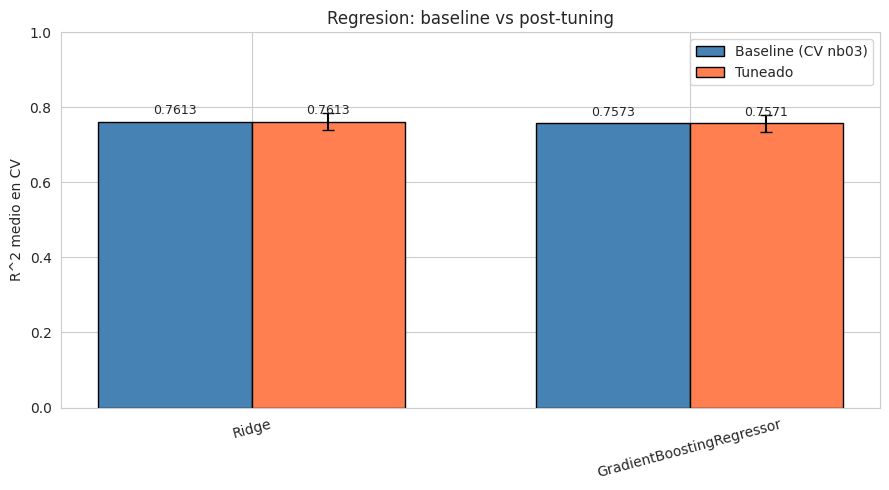

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(reg_compare))
width = 0.35
ax.bar(x - width/2, reg_compare['R2_baseline'], width,
       label='Baseline (CV nb03)', color='steelblue', edgecolor='black')
ax.bar(x + width/2, reg_compare['R2_tuned'], width,
       yerr=reg_compare['R2_tuned_std'], capsize=4,
       label='Tuneado', color='coral', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(reg_compare.index, rotation=15)
ax.set_ylabel('R^2 medio en CV')
ax.set_title('Regresion: baseline vs post-tuning')
ax.legend()
ax.set_ylim(0, 1)
for i, (b, t) in enumerate(zip(reg_compare['R2_baseline'], reg_compare['R2_tuned'])):
    ax.text(i - width/2, b + 0.02, f'{b:.4f}', ha='center', fontsize=9)
    ax.text(i + width/2, t + 0.02, f'{t:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'tuning_regression_compare.png', bbox_inches='tight', dpi=120)
plt.show()


### 3.4 Visualizacion del espacio de busqueda — Ridge

Como Ridge tiene un solo hiperparametro, el espacio se visualiza con una **curva** (R^2 vs alpha en escala log). El optimo deberia ser un maximo claro; si esta en un extremo del grid, hay que ampliar.


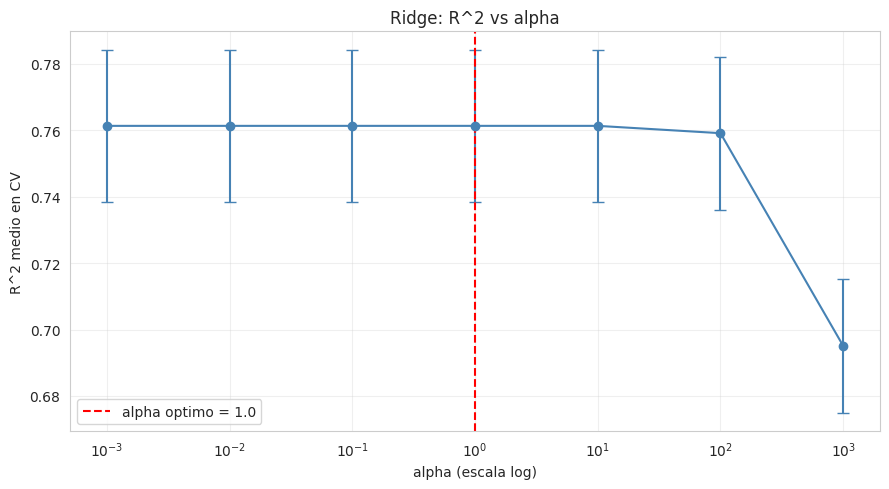

In [11]:
ridge_cv = tune_ridge['cv_results'].copy().sort_values('param_model__alpha')
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(
    ridge_cv['param_model__alpha'].astype(float),
    ridge_cv['mean_test_score'],
    yerr=ridge_cv['std_test_score'],
    marker='o', capsize=4, color='steelblue',
)
ax.set_xscale('log')
ax.set_xlabel('alpha (escala log)')
ax.set_ylabel('R^2 medio en CV')
ax.set_title('Ridge: R^2 vs alpha')
ax.axvline(tune_ridge['best_params']['model__alpha'], color='red', linestyle='--',
           label=f'alpha optimo = {tune_ridge["best_params"]["model__alpha"]}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Clasificacion


### 4.1 LogisticRegression — GridSearchCV

**Por que Grid:** Logistic Regression tiene pocos hiperparametros relevantes y rangos chicos.

**Grid elegido:**

```python
{
    'model__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs', 'liblinear'],
}
```

**Justificacion:**

- `C` es la inversa de la regularizacion (`alpha = 1/C`). Rango log de 6 ordenes para detectar el optimo.
- `penalty='l2'` es el unico tipo aqui — `l1` requeriria solver compatible y suele no aportar nada con OneHot + pocas features numericas.
- `solver`: `lbfgs` es default y robusto; `liblinear` puede converger mejor con datasets chicos. Probar ambos no agrega costo.

Total: `6 * 1 * 2 = 12` candidatos. Trivial de explorar exhaustivamente.


In [12]:
pipe_log = build_classification_pipeline(
    LogisticRegression(random_state=RANDOM_STATE, max_iter=2000), preprocessor
)

log_grid = {
    'model__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs', 'liblinear'],
}

tune_log = run_grid_search(
    pipeline=pipe_log,
    param_grid=log_grid,
    X=X_train, y=y_train_bin,
    cv=CV_FOLDS, scoring='f1',
    stratified=True, random_state=RANDOM_STATE,
)

print(f'LogisticRegression - GridSearchCV ({tune_log["n_candidates"]} candidatos)')
print(f'  Mejores params: {tune_log["best_params"]}')
print(f'  F1 CV: {tune_log["best_score"]:.4f} +- {tune_log["best_score_std"]:.4f}')
print(f'  Baseline F1 (sin tuning): {baseline_clf["LogisticRegression"]:.4f}')
print(f'  Delta: {tune_log["best_score"] - baseline_clf["LogisticRegression"]:+.4f}')


/home/nicolas/U/PrograCien/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/nicolas/U/PrograCien/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/nicolas/U/PrograCien/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be re

LogisticRegression - GridSearchCV (12 candidatos)
  Mejores params: {'model__C': 1.0, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
  F1 CV: 0.8773 +- 0.0069
  Baseline F1 (sin tuning): 0.8771
  Delta: +0.0002


/home/nicolas/U/PrograCien/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/nicolas/U/PrograCien/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/nicolas/U/PrograCien/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be re

In [13]:
export_cv_results_summary(tune_log, top_n=12)


,rank_test_score,mean_test_score,std_test_score,mean_train_score,mean_fit_time,param_model__C,param_model__penalty,param_model__solver
0,1,0.877253,0.006891,0.877533,0.020912,1.000,l2,liblinear
1,2,0.877098,0.007101,0.877631,0.027331,1.000,l2,lbfgs
2,3,0.876243,0.007306,0.877581,0.022995,10.000,l2,lbfgs
3,4,0.876148,0.006898,0.876905,0.030956,0.100,l2,liblinear
4,5,0.876125,0.007328,0.877658,0.018429,10.000,l2,liblinear
5,6,0.876092,0.007417,0.877718,0.016173,100.000,l2,liblinear
6,7,0.875969,0.007240,0.877559,0.025817,100.000,l2,lbfgs
7,8,0.875778,0.006540,0.876808,0.042330,0.100,l2,lbfgs
8,9,0.863940,0.006053,0.863905,0.049129,0.010,l2,liblinear
9,10,0.862157,0.004280,0.863005,0.090476,0.010,l2,lbfgs


### 4.2 GradientBoostingClassifier — RandomizedSearchCV

**Por que Randomized:** mismo argumento que para GBR. Espacio 5-D, busqueda exhaustiva impractica.

Mismo grid que para el regresor — los hiperparametros relevantes son los mismos en el clasificador.


In [14]:
pipe_gbc = build_classification_pipeline(
    GradientBoostingClassifier(random_state=RANDOM_STATE), preprocessor
)

gbc_dist = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
    'model__min_samples_leaf': [1, 5, 10, 20],
    'model__subsample': [0.7, 0.85, 1.0],
}

tune_gbc = run_randomized_search(
    pipeline=pipe_gbc,
    param_distributions=gbc_dist,
    X=X_train, y=y_train_bin,
    n_iter=N_ITER_RANDOMIZED,
    cv=CV_FOLDS, scoring='f1',
    stratified=True, random_state=RANDOM_STATE,
)

print(f'GBC - RandomizedSearchCV ({tune_gbc["n_candidates"]} candidatos)')
print(f'  Mejores params:')
for k, v in tune_gbc['best_params'].items():
    print(f'    {k}: {v}')
print(f'  F1 CV: {tune_gbc["best_score"]:.4f} +- {tune_gbc["best_score_std"]:.4f}')
print(f'  Baseline F1 (sin tuning): {baseline_clf["GradientBoostingClassifier"]:.4f}')
print(f'  Delta: {tune_gbc["best_score"] - baseline_clf["GradientBoostingClassifier"]:+.4f}')


GBC - RandomizedSearchCV (30 candidatos)
  Mejores params:
    model__subsample: 1.0
    model__n_estimators: 300
    model__min_samples_leaf: 10
    model__max_depth: 3
    model__learning_rate: 0.05
  F1 CV: 0.8743 +- 0.0093
  Baseline F1 (sin tuning): 0.8769
  Delta: -0.0026


In [15]:
export_cv_results_summary(tune_gbc, top_n=10)


,rank_test_score,mean_test_score,std_test_score,mean_train_score,mean_fit_time,param_model__subsample,param_model__n_estimators,param_model__min_samples_leaf,param_model__max_depth,param_model__learning_rate
0,1,0.874297,0.009266,0.885204,1.985183,1.00,300,10,3,0.05
1,2,0.874151,0.006937,0.886218,4.928209,0.85,300,1,5,0.01
2,3,0.873450,0.008223,0.886348,1.400463,0.70,100,20,5,0.05
3,4,0.873150,0.008202,0.886713,0.638833,1.00,100,20,3,0.20
4,5,0.873033,0.008798,0.882657,4.636930,0.70,300,20,5,0.01
5,6,0.872911,0.004724,0.892972,3.441424,0.70,500,1,3,0.05
6,7,0.872825,0.006082,0.888324,8.015888,0.85,500,10,5,0.01
7,8,0.871658,0.006499,0.889824,3.037858,1.00,500,5,3,0.05
8,9,0.871279,0.004560,0.898105,1.308578,0.70,200,5,3,0.20
9,10,0.871186,0.006659,0.901073,3.092380,0.85,100,10,7,0.05


### 4.3 Comparacion pre/post tuning — Clasificacion


In [16]:
clf_tuning_results = {
    'LogisticRegression': tune_log,
    'GradientBoostingClassifier': tune_gbc,
}
clf_baselines_subset = {k: baseline_clf[k] for k in clf_tuning_results.keys()}

clf_compare = build_tuning_comparison_table(
    tuning_results=clf_tuning_results,
    baseline_scores=clf_baselines_subset,
    metric_name='F1',
)
clf_compare.to_csv(RESULTS_DIR / 'tuning_classification.csv')
print(f'Tabla exportada a {RESULTS_DIR / "tuning_classification.csv"}')
clf_compare.drop(columns=['best_params']).round(4)


Tabla exportada a /home/nicolas/U/PrograCien/parcial1/results/tuning_classification.csv


,method,F1_baseline,F1_tuned,F1_tuned_std,delta,delta_pct,n_candidates,fit_time_s
Modelo,,,,,,,,
LogisticRegression,GridSearchCV,0.8771,0.8773,0.0069,0.0002,0.0177,12,2.3208
GradientBoostingClassifier,RandomizedSearchCV,0.8769,0.8743,0.0093,-0.0026,-0.2939,30,769.1233


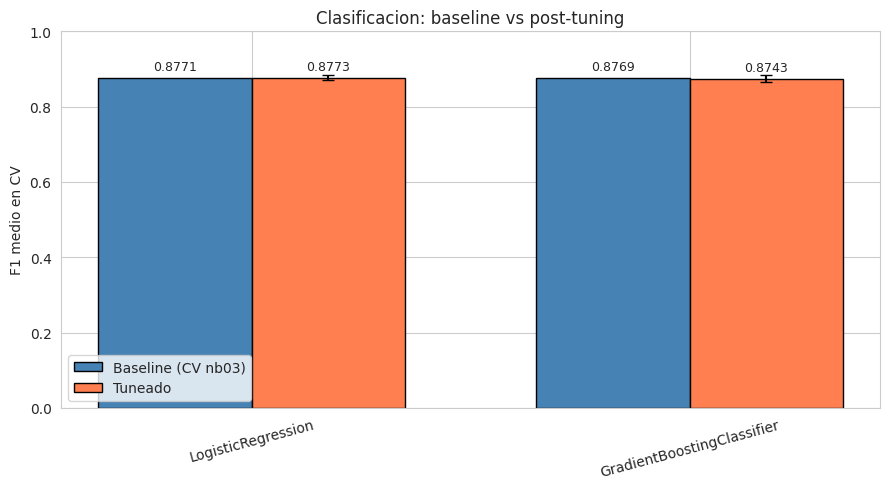

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(clf_compare))
width = 0.35
ax.bar(x - width/2, clf_compare['F1_baseline'], width,
       label='Baseline (CV nb03)', color='steelblue', edgecolor='black')
ax.bar(x + width/2, clf_compare['F1_tuned'], width,
       yerr=clf_compare['F1_tuned_std'], capsize=4,
       label='Tuneado', color='coral', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(clf_compare.index, rotation=15)
ax.set_ylabel('F1 medio en CV')
ax.set_title('Clasificacion: baseline vs post-tuning')
ax.legend()
ax.set_ylim(0, 1)
for i, (b, t) in enumerate(zip(clf_compare['F1_baseline'], clf_compare['F1_tuned'])):
    ax.text(i - width/2, b + 0.02, f'{b:.4f}', ha='center', fontsize=9)
    ax.text(i + width/2, t + 0.02, f'{t:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'tuning_classification_compare.png', bbox_inches='tight', dpi=120)
plt.show()


## 5. Persistir los modelos tuneados

Los mejores estimadores (ya reentrenados sobre `X_train` completo por `refit=True` en el search) se serializan en `models/tuned_*.joblib`. Quedan disponibles para el notebook 05 (analisis final / mejor modelo).


In [18]:
save_model(tune_ridge['best_estimator'], str(MODELS_DIR / 'tuned_ridge.joblib'))
save_model(tune_gbr['best_estimator'], str(MODELS_DIR / 'tuned_gradient_boosting_reg.joblib'))
save_model(tune_log['best_estimator'], str(MODELS_DIR / 'tuned_logistic.joblib'))
save_model(tune_gbc['best_estimator'], str(MODELS_DIR / 'tuned_gradient_boosting_clf.joblib'))

print('Modelos tuneados serializados en models/:')
for p in sorted(MODELS_DIR.glob('tuned_*.joblib')):
    print(f'  {p.name}  ({p.stat().st_size / 1024:.1f} KB)')


Modelos tuneados serializados en models/:
  tuned_gradient_boosting_clf.joblib  (396.6 KB)
  tuned_gradient_boosting_reg.joblib  (393.9 KB)
  tuned_logistic.joblib  (4.1 KB)
  tuned_ridge.joblib  (3.7 KB)


## 6. Evaluacion final en `X_test`

Hasta aqui todas las metricas son **de CV sobre el train set**. Ahora reportamos las metricas en el `X_test` reservado — esta es la unica medida realmente honesta de generalizacion, comparable con la tabla del notebook 02.


In [19]:
from sklearn.metrics import (
    accuracy_score, f1_score, mean_absolute_error,
    mean_absolute_percentage_error, precision_score,
    r2_score, recall_score, roc_auc_score,
)

def reg_metrics(pipe, X, y):
    y_pred = pipe.predict(X)
    return {
        'R2': r2_score(y, y_pred),
        'MAE': mean_absolute_error(y, y_pred),
        'RMSE': float(np.sqrt(((y - y_pred) ** 2).mean())),
        'MAPE': mean_absolute_percentage_error(y, y_pred),
    }

def clf_metrics(pipe, X, y):
    y_pred = pipe.predict(X)
    y_proba = pipe.predict_proba(X)[:, 1]
    return {
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred, zero_division=0),
        'Recall': recall_score(y, y_pred, zero_division=0),
        'F1': f1_score(y, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y, y_proba),
    }

reg_test = pd.DataFrame({
    'Ridge': reg_metrics(tune_ridge['best_estimator'], X_test, y_test),
    'GradientBoostingRegressor': reg_metrics(tune_gbr['best_estimator'], X_test, y_test),
}).T.round(4)
print('Regresion - metricas en test (modelos tuneados):')
print(reg_test.to_string())

clf_test = pd.DataFrame({
    'LogisticRegression': clf_metrics(tune_log['best_estimator'], X_test, y_test_bin),
    'GradientBoostingClassifier': clf_metrics(tune_gbc['best_estimator'], X_test, y_test_bin),
}).T.round(4)
print('\nClasificacion - metricas en test (modelos tuneados):')
print(clf_test.to_string())


Regresion - metricas en test (modelos tuneados):
                               R2         MAE        RMSE    MAPE
Ridge                      0.7473  16560.7283  23786.1297  0.1306
GradientBoostingRegressor  0.7424  16782.1428  24015.4674  0.1329

Clasificacion - metricas en test (modelos tuneados):
                            Accuracy  Precision  Recall      F1  ROC_AUC
LogisticRegression            0.8595     0.8730  0.8490  0.8608   0.9497
GradientBoostingClassifier    0.8622     0.8737  0.8543  0.8639   0.9490


## 7. Conclusiones


In [20]:
print('REGRESION - resumen post-tuning')
print('=' * 70)
for name, res in reg_tuning_results.items():
    base = baseline_reg[name]
    delta = res['best_score'] - base
    n_std = abs(delta) / res['best_score_std'] if res['best_score_std'] > 0 else float('inf')
    print(f'\n{name} ({res["method"]}):')
    print(f'  Mejor R^2: {res["best_score"]:.4f} (baseline {base:.4f}, delta {delta:+.4f})')
    print(f'  Mejora en multiplos de std: {n_std:.2f}x')
    print(f'  Mejores params: {res["best_params"]}')

print('\n\nCLASIFICACION - resumen post-tuning')
print('=' * 70)
for name, res in clf_tuning_results.items():
    base = baseline_clf[name]
    delta = res['best_score'] - base
    n_std = abs(delta) / res['best_score_std'] if res['best_score_std'] > 0 else float('inf')
    print(f'\n{name} ({res["method"]}):')
    print(f'  Mejor F1: {res["best_score"]:.4f} (baseline {base:.4f}, delta {delta:+.4f})')
    print(f'  Mejora en multiplos de std: {n_std:.2f}x')
    print(f'  Mejores params: {res["best_params"]}')


REGRESION - resumen post-tuning

Ridge (GridSearchCV):
  Mejor R^2: 0.7613 (baseline 0.7613, delta +0.0000)
  Mejora en multiplos de std: 0.00x
  Mejores params: {'model__alpha': 1.0}

GradientBoostingRegressor (RandomizedSearchCV):
  Mejor R^2: 0.7571 (baseline 0.7573, delta -0.0001)
  Mejora en multiplos de std: 0.01x
  Mejores params: {'model__subsample': 1.0, 'model__n_estimators': 300, 'model__min_samples_leaf': 10, 'model__max_depth': 3, 'model__learning_rate': 0.05}


CLASIFICACION - resumen post-tuning

LogisticRegression (GridSearchCV):
  Mejor F1: 0.8773 (baseline 0.8771, delta +0.0002)
  Mejora en multiplos de std: 0.02x
  Mejores params: {'model__C': 1.0, 'model__penalty': 'l2', 'model__solver': 'liblinear'}

GradientBoostingClassifier (RandomizedSearchCV):
  Mejor F1: 0.8743 (baseline 0.8769, delta -0.0026)
  Mejora en multiplos de std: 0.28x
  Mejores params: {'model__subsample': 1.0, 'model__n_estimators': 300, 'model__min_samples_leaf': 10, 'model__max_depth': 3, 'model

### Lectura del impacto

Convencion para interpretar el `delta` vs la `std` de CV:

- **`|delta| < 1x std`:** mejora dentro del ruido natural del CV — no es estadisticamente clara.
- **`|delta| entre 1x y 2x std`:** mejora plausible pero modesta.
- **`|delta| > 2x std`:** mejora robusta — vale la pena reportarla en el informe.

Si **Ridge** quedo con `alpha=0.001` (extremo bajo del grid) o `alpha=1000` (extremo alto), conviene ampliar el grid en esa direccion para verificar que el optimo no este afuera. Si quedo en el medio, esta capturado correctamente.

Para **Gradient Boosting**, lo tipico es ver mejoras mas grandes que en Ridge porque el espacio de hiperparametros es mas rico. Si la mejora es chica, significa que los defaults ya estaban cerca del optimo y el modelo es robusto a su configuracion.

### Recomendacion para Fase 7 (notebook 05)

El **modelo ganador final** del proyecto se elige entre los 4 tuneados aqui, considerando:

1. Mejor metrica en test (no en CV — ya seleccionamos via CV).
2. Estabilidad (std de CV baja).
3. Interpretabilidad y costo computacional (Ridge / LogReg son mas simples e interpretables que GBR / GBC).

Si Ridge tuneado iguala a GBR tuneado a 3 decimales, **Ridge es la eleccion racional** por simplicidad. Mismo argumento para LogisticRegression vs GBC en clasificacion.

### Artefactos generados

- `results/tuning_regression.csv`, `results/tuning_classification.csv` — tablas comparativas.
- `results/tuning_regression_compare.png`, `results/tuning_classification_compare.png` — bar plots pre/post.
- `models/tuned_*.joblib` — 4 pipelines tuneados, listos para el notebook 05.
